# ***LifePilot_Simulator***
*with*
**Treament_RiskMangment**
*by*
**1RatLabs**

## Goal

## Usage

## Implementation

### Digital analob computer ***DAC***

#### Class is A Blue print for a specific type of **Instance OR BLOCK**
1. ***Attributes*** specified in the input read from an **input dictionary**
2. ***Methods*** specified by **def** describing a **function involving attributes**
3. ***Outputs*** inserted into an *Output dicctionary* with **specified keys**

#### Block is made by using a Class to specify structure created by __init__ the class and all have same 
1. ***Inputs*** read from an **input dictionary** with **specified keys**
2. ***calculates*** using the **def** specified in the **class**
3. ***Outputs*** inserted into a specified *Output dicctionary* with **specified keys**

#### Blocks use charge, voltage and current as place keepers for biolgical particles, partical flow and particle density
1. ***Charge*** >>> ATP or, ADP, etc
2.  ***Current*** >>> flow of ATP or, ADP, etc
3.  ***Voltage*** >>> ATP or, ADP, etc population density

#### ***Block iteration rate*** must be much higher than the fastest ***input rate*** of change to avoid aliasing errors
1. ***Output Filters*** smooth the flow and elliminate aliasing errors
2. ***Output Filters group and phase delays*** need to be matched
3. ***Iteration outputs*** must be clearly marked and be separate from system operational outputs
4. Run ***system steps*** after the completion of ***iterations***0to reduce aliasing.

# Table_of_Contents

# Reboot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import analog_blocks as ab

importlib.reload(ab)


NameError: name 'BlockBase' is not defined

## Import analog_blocks [ab]

In [44]:
# ab.inspect_block(A)

In [45]:
# import analog_blocks as ab

A = ab.Node("A", initial_V=40)
B = ab.Node("B", initial_V=5)

D = ab.Diffusion(k=0.05, V1=lambda: A.V, V2=lambda: B.V)

A.add_flow(lambda: -D.flow_1_to_2())
B.add_flow(lambda:  D.flow_1_to_2())

CapA = ab.Capacitor(node=A, C=1.0, dt=0.1)
CapB = ab.Capacitor(node=B, C=1.0, dt=0.1)


In [46]:
# verify CapB

In [47]:
# verify CapA.__dict__

# Develop Subsystem_Blocks [ssb]

#### note: always us ab.  prefix 

##### a note on py module use
1. A    = ab.Node("A", initial_V=40)
2. B    = ab.Node("B", initial_V=5
3. D    = ab.Diffusion(k=0.05, V1=lambda: A.V, V2=lambda: B.V)
4. CapA = ab.Capacitor(node=A, C=1.0, dt=0.1)
5. CapB = ab.Capacitor(node=B, C=1.0, dt=0.1)

## Examples : ___Develop Subsystem_Blocks* [ssb]

#### Example ***2 rooms*** ___Develop Subsystem_Blocks* [ssb]

In [48]:
# ============================================================
# DEMO SYSTEM — two compartments exchanging particles
# ============================================================
# all blocks are defined in Analog_blocks.py and therefore need an "ab." prefix
# Create nodes

#A = ab.Node("A", initial_V=10)   # crowded compartment
#B = ab.Node("B", initial_V=2)    # empty compartment
A = ab.Node("A", initial_V=40)   # crowded compartment
B = ab.Node("B", initial_V=5)    # empty compartment

# Create diffusion block          # this is a current source bi directional
D = ab.Diffusion(k=0.05, V1=lambda: A.V, V2=lambda: B.V)   # D current source due to diffusion flow

# Connect flows to nodes               # sets the source or sink of the D current sourc
A.add_flow(lambda: -D.flow_1_to_2())   # A loses particles
B.add_flow(lambda:  D.flow_1_to_2())   # B gains particles

# Add capacitors (storage)             # set the storage that stores the net flow
CapA = ab.Capacitor(C=1.0, node=A, dt=0.1)
CapB = ab.Capacitor(C=1.0, node=B, dt=0.1)




##### Connect

In [49]:
# Connect flows to nodes
# import analog_blocks as ab

A.add_flow(lambda: -D.flow_1_to_2())   # sources flows D   A loses particles
B.add_flow(lambda:  D.flow_1_to_2())   # sinks flows D     B gains particles

# Add capacitors (storage)
CapA = ab.Capacitor(C=1.0, node=A, dt=0.1)
CapB = ab.Capacitor(C=1.0, node=B, dt=0.1)

In [50]:
# verify CapA.__dict__

#### Example ***2_stages*** *___Develop Subsystem_Blocks* [ssb]

In [51]:
stage1 = ab.NegGainOpAmp("Stage1", Rin=10_000, Rf=20_000)
stage2 = ab.NegGainOpAmp("Stage2", Rin=5_000,  Rf=15_000)

In [52]:
# verify stage1.__dict__

In [53]:
# verify stage2.__dict__

### Test the Example

##### Create Dict of history with a iteration loop

In [54]:
# ============================================================
# SIMULATION LOOP
# CapA.update()
# CapB.update()

# ============================================================

dt = 0.1                           # step size 
steps = 300                        # number of steps

A_history = []                      # list starts with A_history[0] and calcs the charge[A people] in room at each step
B_history = []                      # list starts with B_history[0] and calcs the charge[B people] in room at each step

for _ in range(steps):
    CapA.update()                 # Updates the charge by [I*dt] or capitor voltage = [Q/C] in the capacitorA for each calc
    CapB.update()                 # ditto for B
    A_history.append(A.V)         # Append adds another value to a list
    B_history.append(B.V)


In [55]:
# verify A_history                # 

##### Plot the Dict

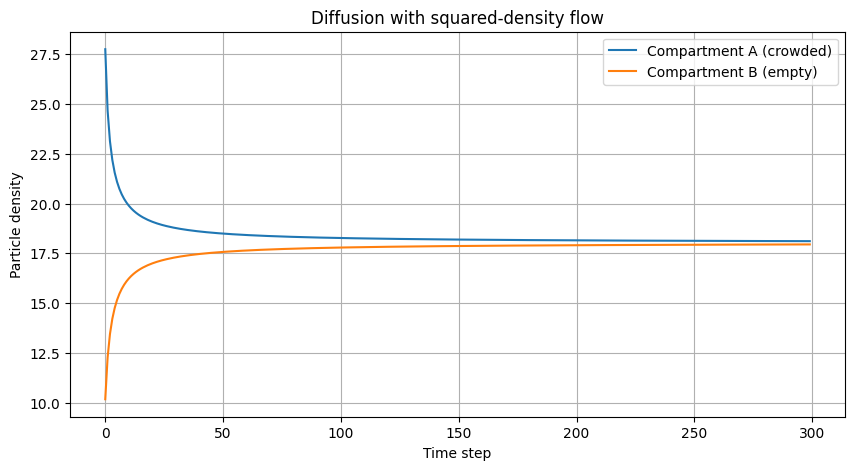

In [56]:
# ============================================================
# PLOT RESULTS
# ============================================================

plt.figure(figsize=(10,5))
plt.plot(A_history, label="Compartment A (crowded)")
plt.plot(B_history, label="Compartment B (empty)")
plt.xlabel("Time step")
plt.ylabel("Particle density")
plt.title("Diffusion with squared-density flow")
plt.legend()
plt.grid(True)
plt.show()

## Develop System_Blocks [sb]

In [57]:
amp = ab.NegGainOpAmp("Stage1", Rin=10000, Rf=20000)
dl = ab.DelayLine("Demo", tap_weights={0:1,1:-0.5})

In [58]:
amp

In [59]:
amp.__dict__

{'name': 'Stage1', 'Rin': 10000, 'Rf': 20000, 'gain': -10000}

In [60]:
dir(amp)

['Rf',
 'Rin',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'compute',
 'gain',
 'name']

In [64]:
info = ab.inspect_block(ab.NegGainOpAmp ) 

In [68]:
info

{'class': 'NegGainOpAmp',
 'attributes': {'name': 'Stage1', 'Rin': 10000, 'Rf': 20000, 'gain': -10000},
 'methods': ['compute']}

In [69]:
print(ab.summarize_block(amp))


Block Summary: NegGainOpAmp
--------------------------------------------------
Attributes:
  • name: Stage1
  • Rin: 10000
  • Rf: 20000
  • gain: -10000

Methods:
  • compute
